# Model Training

### scikit - learn

https://scikit-learn.org/stable/

scikitlearn (sklearn) provides simple and efficient tools for predictive data analysis. It is built on NumPy, SciPy, and matplotlib.

First thing, Import all the libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.max_columns', 50)
 # import linear regression model
from sklearn.linear_model import LinearRegression
# import module for train test split
from sklearn.model_selection import train_test_split

In [4]:
# next load the data
df = pd.read_csv('final.csv')
df.head()

,price,year_sold,property_tax,insurance,beds,baths,sqft,year_built,lot_size,basement,popular,recession,property_age,property_type_Condo
0,295850,2013,234,81,1,1,584,2013,0,0,0,1,0,1
1,216500,2006,169,51,1,1,612,1965,0,0,0,0,41,1
2,279900,2012,216,74,1,1,615,1963,0,0,0,1,49,1
3,379900,2005,265,92,1,1,618,2000,33541,1,0,0,5,0
4,340000,2002,88,30,1,1,634,1992,0,0,0,0,10,1


In [5]:
df.tail()

,price,year_sold,property_tax,insurance,beds,baths,sqft,year_built,lot_size,basement,popular,recession,property_age,property_type_Condo
1855,760000,2008,881,249,5,5,7842,2003,436035,1,0,0,5,0
1856,690000,2015,1553,473,5,6,6501,1956,23086,1,0,0,59,0
1857,600000,1999,942,287,5,6,7064,1995,217800,1,0,0,4,0
1858,759900,2009,803,245,5,6,7500,2006,8886,1,0,0,3,0
1859,735000,2015,1459,444,5,6,7515,1958,10497,1,0,0,57,0


In [6]:
df.shape

(1860, 14)

## Linear Regression Model

In [7]:
# seperate input features in x
x = df.drop('price', axis=1) # axis=1 will drop a column.

# store the target variable in y
y = df['price']

**Train Test Split**
* Training sets are used to fit and tune your models.
* Test sets are put aside as "unseen" data to evaluate your models.
* The `train_test_split()` function splits data into randomized subsets.

## First Train / Test split

In [8]:
# Split the dataset
# i hwant equal number of proprterype condo in may split (stratify =)
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, stratify=x.property_type_Condo)

In [9]:
x_train.property_type_Condo.value_counts()

property_type_Condo
0    1208
1     280
Name: count, dtype: int64

In [10]:
x_train.head()

,year_sold,property_tax,insurance,beds,baths,sqft,year_built,lot_size,basement,popular,recession,property_age,property_type_Condo
1682,2000,553,142,5,3,4000,2000,11761,1,0,0,0,0
270,2012,379,115,2,2,1204,1995,0,0,1,1,17,1
1037,2004,549,167,4,2,1868,1973,12196,1,0,0,31,0
1078,2016,306,87,4,2,2298,2004,4007,1,0,0,12,0
1552,2004,731,207,4,4,6050,2004,110206,1,0,0,0,0


## Size of each Vector

In [11]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((1488, 13), (1488,), (372, 13), (372,))

## Build Linear Regression model on Training set

In [12]:
# train your model
model = LinearRegression()
lrmodel = model.fit(x_train, y_train)

In [13]:
lrmodel.coef_

array([ 8.30740574e+03, -6.68037767e+01,  1.68796538e+03,  3.27098347e+03,
       -1.74178639e+02,  1.47321224e+01,  4.57608106e+03,  1.04082873e-01,
        1.10915085e+04,  4.95446825e+03, -4.97274938e+04,  3.73132468e+03,
       -1.10915085e+04])

In [14]:
lrmodel.intercept_

np.float64(-25657558.34610277)

In [15]:
x_train.head(1)

,year_sold,property_tax,insurance,beds,baths,sqft,year_built,lot_size,basement,popular,recession,property_age,property_type_Condo
1682,2000,553,142,5,3,4000,2000,11761,1,0,0,0,0


## Now Make predictions on Training Set

In [16]:
# make preditions on train set
train_pred = lrmodel.predict(x_train)

In [17]:
train_pred

array([399240.33558634, 386520.16331669, 432592.77086863, ...,
       363035.32849987, 445072.21300181, 427420.27983545], shape=(1488,))

## Compute the Model Error

In [18]:
# evaluate your model
# we need mean absolute error
from sklearn.metrics import mean_absolute_error

train_mae = mean_absolute_error(train_pred, y_train)
print('Train error is', train_mae)

Train error is 83189.90809859624


## Now Make predictions on Test Set

In [19]:
# make predictions on test set
ypred = lrmodel.predict(x_test)

#evaluate the model
test_mae = mean_absolute_error(ypred, y_test)
print('Test error is', test_mae)

Test error is 87212.36063843711


### Our model is still not good beacuse we need a model with Mean Absolute Error < $70,000

Note - We have not scaled the features and not tuned the model.

## Random Forest Model

In [20]:
# import decision tree model
from sklearn.ensemble import RandomForestRegressor

In [21]:
# create an instance of the model
rf = RandomForestRegressor(n_estimators=200, criterion='absolute_error')

In [22]:
# train the model
rfmodel = rf.fit(x_train,y_train)

In [23]:
# make prediction on train set
ytrain_pred = rfmodel.predict(x_train)

In [24]:
# make predictions on the x_test values
ytest_pred = rfmodel.predict(x_test)

In [25]:
# evaluate the model
test_mae = mean_absolute_error(ytest_pred, y_test)
test_mae

48612.800779569894

[Text(0.49105298343120807, 0.9772727272727273, 'insurance <= 132.5\nabsolute_error = 123435.811\nsamples = 943\nvalue = 385000.0'),
 Text(0.26296971126957497, 0.9318181818181818, 'insurance <= 97.5\nabsolute_error = 67158.702\nsamples = 529\nvalue = 325000.0'),
 Text(0.37701134735039155, 0.9545454545454546, 'True  '),
 Text(0.13570825177106638, 0.8863636363636364, 'insurance <= 78.5\nabsolute_error = 46267.4\nsamples = 272\nvalue = 289000.0'),
 Text(0.07573173005219985, 0.8409090909090909, 'property_age <= 34.5\nabsolute_error = 34134.263\nsamples = 120\nvalue = 253000.0'),
 Text(0.03444258016405667, 0.7954545454545454, 'year_sold <= 2007.5\nabsolute_error = 34720.211\nsamples = 84\nvalue = 269000.0'),
 Text(0.011968680089485458, 0.75, 'year_sold <= 2004.5\nabsolute_error = 28918.859\nsamples = 42\nvalue = 295000.0'),
 Text(0.0035794183445190158, 0.7045454545454546, 'sqft <= 782.0\nabsolute_error = 26313.278\nsamples = 11\nvalue = 266200.0'),
 Text(0.0023862788963460104, 0.659090909090

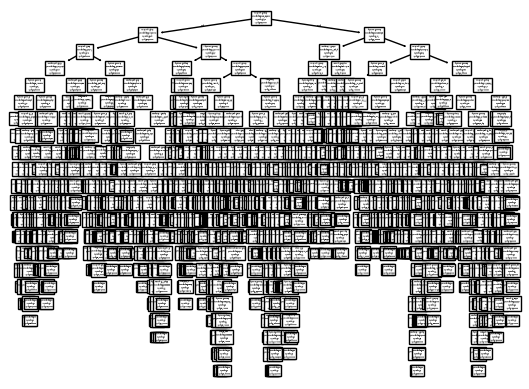

In [26]:
# Individual Decision Trees
from sklearn import tree

tree.plot_tree(rfmodel.estimators_[2], feature_names=rfmodel.feature_names_in_)

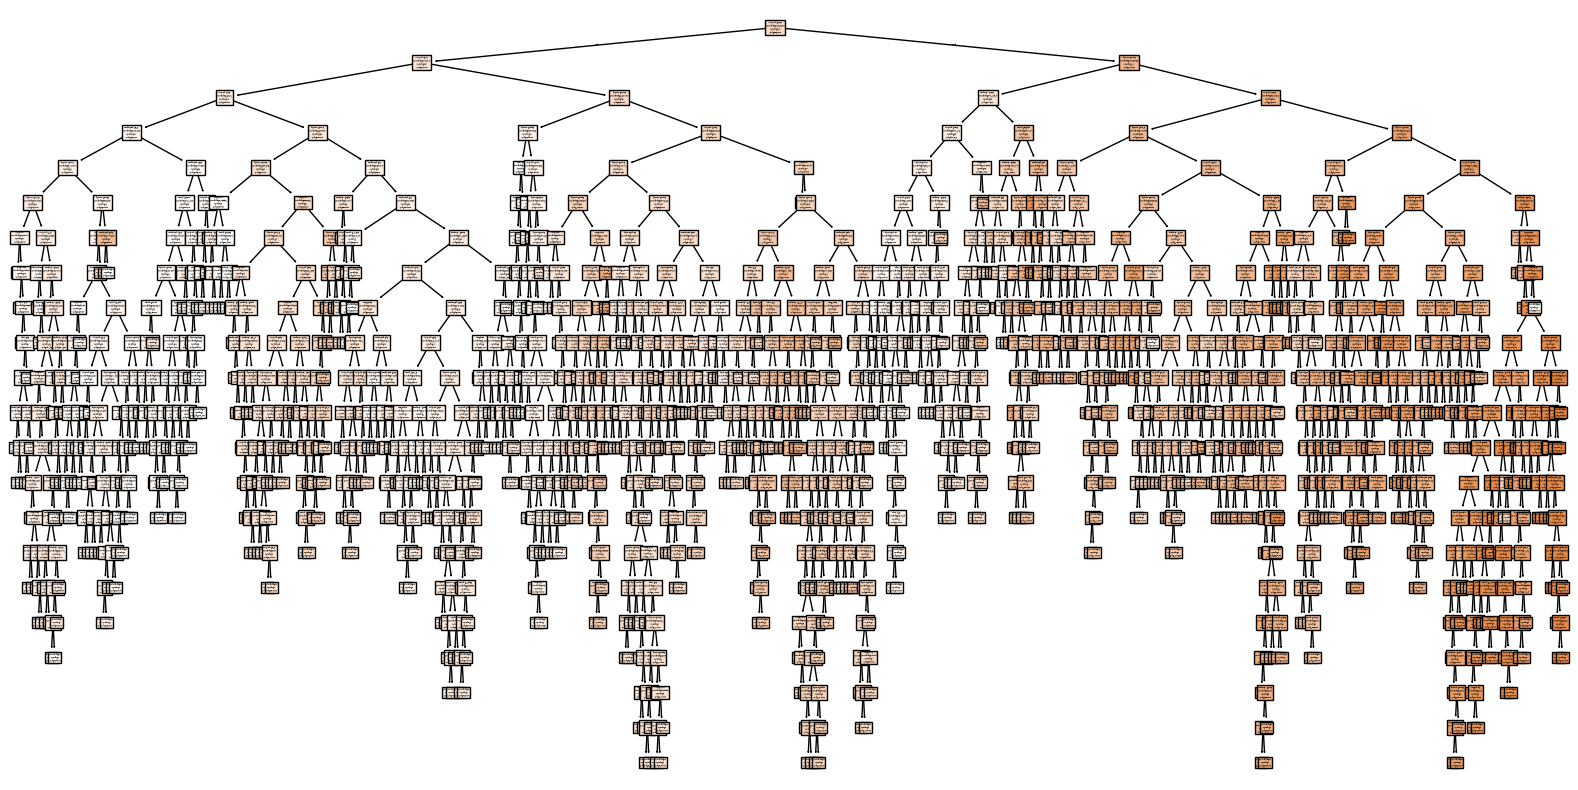

In [27]:
from sklearn import tree

plt.figure(figsize=(20, 10))
tree.plot_tree(
    rfmodel.estimators_[2],
    feature_names=x_train.columns,
    filled=True
)
plt.show()

## Pickle:

* The pickle module implements a powerful algorithm for serializing and de-serializing a Python object structure.

* The saving of data is called Serialization, and loading the data is called De-serialization.

**Pickle** model provides the following functions:
* **`pickle.dump`** to serialize an object hierarchy, you simply use `dump()`.
* **`pickle.load`** to deserialize a data stream, you call the `loads()` function.

In [28]:
# import pickle to save model
import pickle

# Save the trained model on the drive
pickle.dump(rfmodel, open('RE_Model','wb'))

In [29]:
# Load the pickled model
RE_Model = pickle.load(open('RE_Model','rb'))

In [30]:
# Use the loaded pickled model to make predictions
RE_Model.predict([[2012, 216, 74, 1 , 1, 618, 2000, 600, 1, 0, 0, 6, 0]])

d:\BISI\BISI-S2\D_ML_2\Project\1_real_estate\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([247708.52])

In [31]:
x_test.head(1)

,year_sold,property_tax,insurance,beds,baths,sqft,year_built,lot_size,basement,popular,recession,property_age,property_type_Condo
1344,2009,737,245,4,3,2938,1939,8416,1,0,0,70,0
